# Grouping

In this lesson we will go over the split-apply-combine strategy and the groupby() function.

# Learning Objectives

- Understand and apply the Split-Apply-Combine strategy to analyze grouped data.
- Use `groupby()` to split a `pandas.DataFrame` by one or more columns.
- Calculate summary statistics for groups in a `pandas.DataFrame`.
- Use method chaining for readable data analysis.
- Explain how `groupby()` handles NA values and choose between `count()` and `size()` to count observations in each group.


# Data

We will use the Palmer Penguins dataset [2] developed by Drs. Allison Horst, Alison Hill and Kristen Gorman. This dataset contains size measurements for three penguin species in the Palmer Archipelago, Antarctica during 2007, 2008, and 2009.

In [1]:
import numpy as np
import pandas as pd

# Load Palmer penguins data
URL = 'https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv'
penguins = pd.read_csv(URL)

penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


# Summary Statistics

Methods:

- sum(): sum values in each column,
- count(): count non-NA values in each column,
- size(): count the number of values in a column (including NA values),
- min() and max(): get the minimum and maximum value in each column,
- mean() and median(): get the mean and median value in each column,
- std() and var(): get the standard deviation and variance in each column.

*Example*

In [2]:
# Get the number of non-NA values in each column 
penguins.count()

species              344
island               344
bill_length_mm       342
bill_depth_mm        342
flipper_length_mm    342
body_mass_g          342
sex                  333
year                 344
dtype: int64

In [3]:
# Get minimum value in each column with numerical values
penguins.select_dtypes('number').min()

bill_length_mm         32.1
bill_depth_mm          13.1
flipper_length_mm     172.0
body_mass_g          2700.0
year                 2007.0
dtype: float64

# Grouping - `groupby()`

Our penguins data is naturally split into different groups: there are three different species, two sexes (with some missing values), and three islands. Often, we want to calculate a certain statistic for each group. For example, suppose we want to calculate the average flipper length per species. How would we do this “by hand”?

0. We start eith our data and notice there are multiple species in the species column.
1. We split our original table to group all observations from the same species together.
2. We calculate the average flipper length for each of the groups we formed.
3. Then we combine the values for average flipper length per species into a single table.

This is known as the **Split-Apply-Combine** strategy. This strategy follows the three steps we explained above:

**Split**: Split the data into logical groups (e.g. species, sex, island, etc.)

**Apply**: Calculate some summary statistic on each group (e.g. average flipper length by species, number of individuals per island, body mass by sex, etc.)

**Combine**: Combine the statistic calculated on each group back together.

For a pandas.DataFrame or pandas.Series, we can use the groupby() method to split (i.e. group) the data into different categories.

The general syntax for groupby() is

```python
df.groupby(columns_to_group_by).summary_method()
```

Most often, `columns_to_group_by` is a single column name (a string) or a list of column names. The unique values of the column (or columns) will be used as the groups of the data frame.


*Example* - If we don’t use groupby() and directly apply the mean() method to our flipper length column, we obtain the average of all the values in the column:

In [4]:
penguins['flipper_length_mm'].mean()

200.91520467836258

To get the mean flipper length by species we first group our dataset by the species column’s values. However, if we just use the `groupby()` method without specifying what we wish to calculate on each group, not much happens up front:

In [5]:
penguins.groupby('species')['flipper_length_mm']

We get a GroupBy object, which is an intermediate step. It doesn’t perform the actual calculations until we specify an operation:

In [6]:
# Average flipper length per species
penguins.groupby('species')['flipper_length_mm'].mean()

species
Adelie       189.953642
Chinstrap    195.823529
Gentoo       217.186992
Name: flipper_length_mm, dtype: float64

Let's recap what happened in that line (the . can be read as “and then…”):

start with the `penguins` data frame, and then…
use `groupby()` to group the data frame by `species` values, and then…
select the 'flipper_length_mm' column, and then…
calculate the `mean()` of this column with respect to the groups.
Notice that the name of the series is the same as the column on which we calculated the summary statistic. We can easily update this using the `rename() method:

In [9]:
# Average flipper length per species
avg_flipper = (penguins.groupby('species')
                        ['flipper_length_mm']
                        .mean()
                        .rename('mean_flipper_length')
                        .sort_values(ascending=False)
                        )
avg_flipper

species
Gentoo       217.186992
Chinstrap    195.823529
Adelie       189.953642
Name: mean_flipper_length, dtype: float64

We can also group by combinations of columns.

*Example* :

Suppose we want to know the mean flipper length, this time by examining separately penguin species surveyed on each island.

In [10]:
# Average flipper length per species and island
avg_flipper_species_island = (penguins.groupby(['species','island'])
                                ['flipper_length_mm']
                                .mean()
                                .rename('mean_flipper_length')
                                .sort_values(ascending=False)
                                )
avg_flipper_species_island

species    island   
Gentoo     Biscoe       217.186992
Chinstrap  Dream        195.823529
Adelie     Torgersen    191.196078
           Dream        189.732143
           Biscoe       188.795455
Name: mean_flipper_length, dtype: float64

# Grouping and NA Values


Notice first that 11 penguins have no recorded sex. We can check this using:

`size`: returns the number of observations in a `pandas.Series`
`count()`: returns the number of non-NA observations in the series

In [11]:
# Number of NA observations
penguins['sex'].size - penguins['sex'].count()

11

By default, `groupby()` leaves out the rows where the grouping column has NA values. When we group by `sex` and count the number of observations (rows) we are left with, the 11 NA values are not included:

In [12]:
penguins.groupby('sex').size()

sex
female    165
male      168
dtype: int64

To keep the NA values as their own group, we use the `dropna=False` parameter:

In [13]:
penguins.groupby('sex', dropna=False).size()

sex
female    165
male      168
NaN        11
dtype: int64

# Check-In

Discuss the differences between each output. What method would give you the number of penguins surveyed on each island and year combination?

In [14]:
penguins.groupby(['island','year']).count()

species  bill_length_mm  bill_depth_mm  flipper_length_mm  \
island    year                                                              
Biscoe    2007       44              44             44                 44   
          2008       64              64             64                 64   
          2009       60              59             59                 59   
Dream     2007       46              46             46                 46   
          2008       34              34             34                 34   
          2009       44              44             44                 44   
Torgersen 2007       20              19             19                 19   
          2008       16              16             16                 16   
          2009       16              16             16                 16   

                body_mass_g  sex  
island    year                    
Biscoe    2007           44   43  
          2008           64   63  
          2009           59   57  
Dream     2007           46   45  
          2008           34   34  
          2009           44   44  
Torgersen 2007           19   15  
          2008           16   16  
          2009           16   16

In [16]:
penguins.groupby(['island','year']).size() # returns number of rows in each group?

island     year
Biscoe     2007    44
           2008    64
           2009    60
Dream      2007    46
           2008    34
           2009    44
Torgersen  2007    20
           2008    16
           2009    16
dtype: int64

`.size()` gives only the count of our variable of interest grouped by the parameters given.

`.count()` gives a dataframe with count of all the columns but are grouped by the parameters given

Let’s say we want to plot the surveyed population per year and island. We could then use method chaining to do this:


<Axes: title={'center': 'Penguins surveyed at the Palmer Archipelago'}, xlabel='Number of penguins', ylabel='Island, Year'>

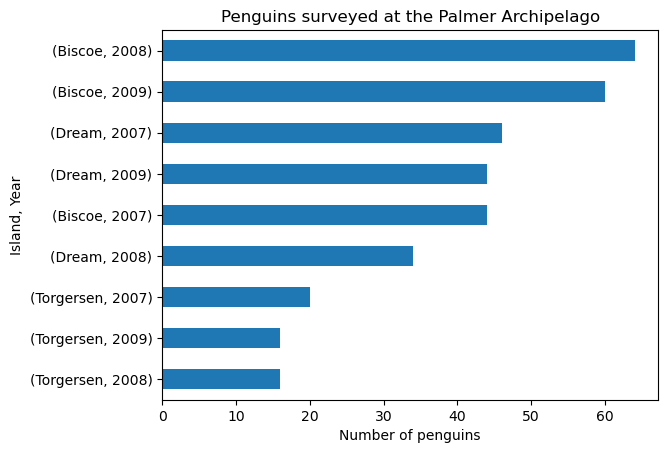

In [17]:
(penguins.groupby(['island','year'])
         .size()
         .sort_values()
         .plot(kind='barh',
                title='Penguins surveyed at the Palmer Archipelago',
                xlabel='Number of penguins',
                ylabel='Island, Year')
         )

# Check-In

Use the `max()` method to calculate the maximum value of a penguin’s body mass by year and species.

In [19]:
penguins.groupby(['species','year'])['body_mass_g'].max()

species    year
Adelie     2007    4675.0
           2008    4700.0
           2009    4775.0
Chinstrap  2007    4400.0
           2008    4800.0
           2009    4450.0
Gentoo     2007    6300.0
           2008    6000.0
           2009    6000.0
Name: body_mass_g, dtype: float64




Display the highest body masses per year and species as a bar plot in descending order.

<Axes: title={'center': 'Body Mass of Penguins surveyed at the Palmer Archipelago'}, xlabel='Body Mass (g)', ylabel='Species, Year'>

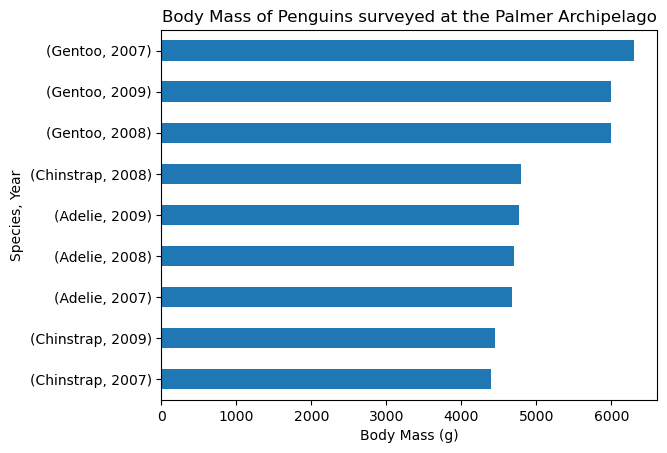

In [25]:
(penguins.groupby(['species','year'])['body_mass_g'].max()
         .sort_values()
         .plot(kind='barh',
                title='Body Mass of Penguins surveyed at the Palmer Archipelago',
                xlabel='Body Mass (g)',
                ylabel='Species, Year')
         )